In [1]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.2 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pmdarima import auto_arima
import pickle
from sklearn.metrics import mean_absolute_error, mean_squared_error
from datetime import datetime

In [3]:
df = pd.read_csv("fire_incidents.csv", encoding='latin1')

In [4]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df = df.dropna(subset=['Date'])

In [5]:
monthly_data = df.groupby(pd.Grouper(key='Date', freq='ME')).size()

In [ ]:
# Keep only 2022
monthly_data = monthly_data[monthly_data.index.year == 2022]

In [ ]:
full_range = pd.date_range('2022-01-01', '2022-12-31', freq='ME')
monthly_data = monthly_data.reindex(full_range, fill_value=0)
monthly_data.index = monthly_data.index.strftime('%Y-%m')

print("2022 Monthly Fire Incidents:")
print(monthly_data)

2022 Monthly Fire Incidents:
2022-01    18
2022-02     8
2022-03    12
2022-04    14
2022-05    16
2022-06    17
2022-07    17
2022-08    20
2022-09    11
2022-10    15
2022-11    20
2022-12    12
dtype: int64


In [ ]:
# 70/15/15 Split
n = len(monthly_data)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train = monthly_data.iloc[:train_end]
val = monthly_data.iloc[train_end:val_end]
test = monthly_data.iloc[val_end:]

print(f"\n70/15/15 Split → Train: {len(train)} | Val: {len(val)} | Test: {len(test)} months")


70/15/15 Split → Train: 8 | Val: 2 | Test: 2 months


In [ ]:
print("Training auto_arima...")
model = auto_arima(
    train,
    seasonal=True, m=12,
    start_p=0, start_q=0, max_p=5, max_q=5,
    d=1, D=0, trace=True,
    error_action='ignore', suppress_warnings=True, stepwise=True
)
forecast_val_test = model.predict(n_periods=len(val) + len(test))
forecast_test = forecast_val_test[len(val):]

Training auto_arima...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=44.499, Time=0.07 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=inf, Time=1.10 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=inf, Time=0.38 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=42.529, Time=0.03 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=46.499, Time=0.02 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : AIC=46.499, Time=0.02 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=48.499, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=45.058, Time=0.03 sec


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1901: RuntimeWarning: divide by zero encountered in reciprocal
  return np.roots(self.polynomial_reduced_ar)**-1
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1908: RuntimeWarning: divide by zero encountered in reciprocal
  return np.roots(self.polynomial_reduced_ma)**-1
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1901: RuntimeWarning: divide by zero encountered in reciprocal
  return np.roots(self.polynomial_reduced_ar)**-1
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1908: RuntimeWarning: divide by zero encountered in reciprocal
  return np.roots(self.polynomial_reduced_ma)**-1


 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=inf, Time=0.10 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : AIC=inf, Time=0.17 sec

Best model:  ARIMA(0,1,0)(0,0,0)[12]          
Total fit time: 1.940 seconds


In [ ]:
mae = mean_absolute_error(test, forecast_test)
rmse = np.sqrt(mean_squared_error(test, forecast_test))
mape = np.mean(np.abs((test - forecast_test) / (test + 1))) * 100

print(f"\nTest Results:")
print(f"MAE  : {mae:.2f} incidents")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.1f}%")


Test Results:
MAE  : 4.00 incidents
RMSE : 5.66
MAPE : nan%


In [ ]:
print("\nRetraining final model on train + validation...")
train_val = pd.concat([train, val])
final_model = auto_arima(
    train_val,
    seasonal=True, m=12,
    start_p=0, start_q=0, max_p=5, max_q=5,
    d=1, D=0, trace=True,
    error_action='ignore', suppress_warnings=True, stepwise=True
)

print(final_model.summary())


Retraining final model on train + validation...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=62.709, Time=0.15 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=58.709, Time=0.04 sec


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1901: RuntimeWarning: divide by zero encountered in reciprocal
  return np.roots(self.polynomial_reduced_ar)**-1
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1908: RuntimeWarning: divide by zero encountered in reciprocal
  return np.roots(self.polynomial_reduced_ma)**-1


 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=inf, Time=0.83 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=inf, Time=0.19 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=56.748, Time=0.02 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=60.709, Time=0.02 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : AIC=60.709, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=58.187, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=inf, Time=0.07 sec


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1901: RuntimeWarning: divide by zero encountered in reciprocal
  return np.roots(self.polynomial_reduced_ar)**-1
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1908: RuntimeWarning: divide by zero encountered in reciprocal
  return np.roots(self.polynomial_reduced_ma)**-1


 ARIMA(1,1,1)(0,0,0)[12] intercept   : AIC=inf, Time=0.14 sec

Best model:  ARIMA(0,1,0)(0,0,0)[12]          
Total fit time: 1.534 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   10
Model:               SARIMAX(0, 1, 0)   Log Likelihood                 -27.374
Date:                Thu, 18 Dec 2025   AIC                             56.748
Time:                        15:34:38   BIC                             56.945
Sample:                    01-01-2022   HQIC                            56.322
                         - 10-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2        25.6666     12.418      2.067      0.039       1.329    

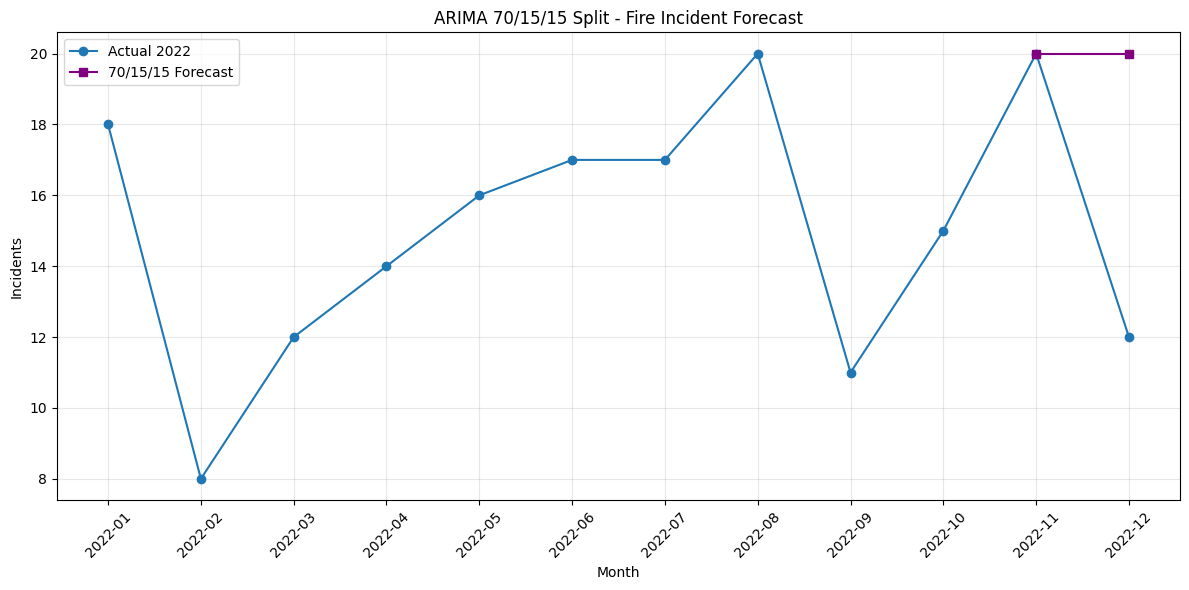

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(monthly_data.index, monthly_data.values, label='Actual 2022', marker='o')
plt.plot(test.index, forecast_test, label='70/15/15 Forecast', marker='s', color='purple')
plt.title('ARIMA 70/15/15 Split - Fire Incident Forecast')
plt.xlabel('Month'); plt.ylabel('Incidents')
plt.legend(); plt.grid(True, alpha=0.3); plt.xticks(rotation=45)
plt.tight_layout(); plt.show()

In [ ]:
with open('fire_forecast_70_15_15.pkl', 'wb') as f:
    pickle.dump(final_model, f)

# TRAINING SARIMAX

In [7]:
# 1. Split the monthly_data into training (70%) and test (30%) sets.
n = len(monthly_data)
train_end = int(n * 0.70)

train = monthly_data.iloc[:train_end]
test = monthly_data.iloc[train_end:]
# Create an empty 'val' set for compatibility with subsequent steps that might expect it, even if it's not used.
val = pd.Series([], dtype=monthly_data.dtype)

print(f"Data Split → Train: {len(train)} | Test: {len(test)} months")



Data Split → Train: 53 | Test: 24 months


In [8]:
# 2. Train an auto_arima model on the training data (train).
print("\nTraining auto_arima on train data...")
model = auto_arima(
    train,
    seasonal=True, m=12,
    start_p=0, start_q=0, max_p=5, max_q=5,
    d=1, D=0, trace=False,
    error_action='ignore', suppress_warnings=True, stepwise=True
)




Training auto_arima on train data...


In [9]:
# 3. Forecast values for the validation and test periods.
# Forecast for the combined length of validation and test sets
forecast_val_test = model.predict(n_periods=len(val) + len(test))
# Extract forecast for the test period only
forecast_test = forecast_val_test[len(val):] # len(val) is 0, so this effectively takes all forecast_val_test

# Align forecast_test index with actual test index for proper plotting and metrics
forecast_test_series = pd.Series(forecast_test, index=test.index)



In [10]:
# 4. Calculate and print the Mean Absolute Error (MAE), Root Mean Squared Error (RMSE),
# and Mean Absolute Percentage Error (MAPE) for the test set.
# Ensure the MAPE calculation is robust to zero actual values.
mae = mean_absolute_error(test, forecast_test_series)
rmse = np.sqrt(mean_squared_error(test, forecast_test_series))

# Robust MAPE calculation: add a small epsilon to denominator to avoid division by zero
def calculate_mape_robust(y_true, y_pred):
    # Convert to numpy arrays for element-wise operations
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Avoid division by zero by adding a small epsilon to y_true
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    return mape

mape = calculate_mape_robust(test, forecast_test_series)

print(f"\nTest Results (70/30 Split):")
print(f"MAE  : {mae:.2f} incidents")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.1f}%")




Test Results (70/30 Split):
MAE  : 0.53 incidents
RMSE : 0.57
MAPE : 3886012709.7%


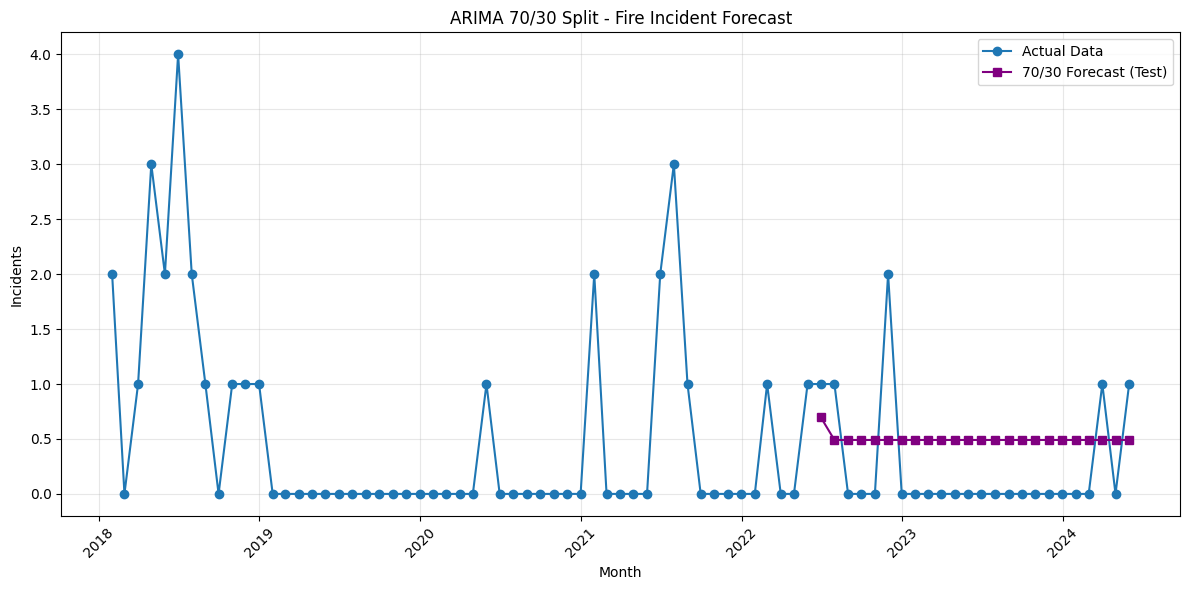

In [11]:
# 5. Plot the actual data, along with the forecasted values for the test set.
plt.figure(figsize=(12, 6))
plt.plot(monthly_data.index, monthly_data.values, label='Actual Data', marker='o')
plt.plot(forecast_test_series.index, forecast_test_series, label='70/30 Forecast (Test)', marker='s', color='purple')
plt.title('ARIMA 70/30 Split - Fire Incident Forecast')
plt.xlabel('Month')
plt.ylabel('Incidents')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [12]:
# 6. Retrain a final auto_arima model using the combined training and validation data (train_val).
# With a 70/30 split and empty 'val', train_val is effectively just 'train'.
print("\nRetraining final model on train + validation data (effectively just train for 70/30 split)...")
train_val = pd.concat([train, val])
final_model = auto_arima(
    train_val,
    seasonal=True, m=12,
    start_p=0, start_q=0, max_p=5, max_q=5,
    d=1, D=0, trace=False,
    error_action='ignore', suppress_warnings=True, stepwise=True
)

print("\nFinal Model Summary (Trained on Train + Val):")
print(final_model.summary())




Retraining final model on train + validation data (effectively just train for 70/30 split)...


/tmp/ipython-input-722720994.py:4: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  train_val = pd.concat([train, val])



Final Model Summary (Trained on Train + Val):
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   53
Model:               SARIMAX(0, 1, 2)   Log Likelihood                 -64.325
Date:                Sun, 11 Jan 2026   AIC                            134.649
Time:                        08:29:21   BIC                            140.503
Sample:                    01-31-2018   HQIC                           136.893
                         - 05-31-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.4557      0.129     -3.529      0.000      -0.709      -0.203
ma.L2         -0.2801      0.142     -1.976      0.048      -0.558      -0.002
sigma

In [13]:
# 7. Save the final retrained model as 'fire_forecast_sarimax_70_30.pkl'.
with open('fire_forecast_sarimax_70_30.pkl', 'wb') as f:
    pickle.dump(final_model, f)
print("\nFinal model saved as 'fire_forecast_sarimax_70_30.pkl'")


Final model saved as 'fire_forecast_sarimax_70_30.pkl'
